In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RANSACRegressor 

In [2]:
klio_df = pd.read_excel('data/Klio_CID_unique_preferred_Imax_FIXED.xlsx')
klio_df.head()

,CID,Canonical_Name,CAS,Preferred_Imax,N_records,Sources,Imax_mean,Imax_min,Imax_max,Klio_names,SMILES,IUPACName
0,107,3-PHENYLPROPIONIC ACID,501-52-0,46.0,1,Original,46.0,46.0,46.0,phrenyl propionic acid-3,C1=CC=C(C=C1)CCC(=O)O,3-phenylpropanoic acid
1,125,4-HYDROXYBENZYL ALCOHOL,623-05-2,17.0,1,Original,17.0,17.0,17.0,NaN,C1=CC(=CC=C1CO)O,4-(hydroxymethyl)phenol
2,176,ACETIC ACID,64-19-7,100.0,2,Reevaluation,100.0,100.0,100.0,NaN,CC(=O)O,acetic acid
3,177,ACETALDEHYDE,75-07-0,59.0,1,Reevaluation,59.0,59.0,59.0,acetaldehyde,CC=O,acetaldehyde
4,179,ACETOIN NATURAL,513-86-0,49.0,2,Reevaluation,49.0,49.0,49.0,acetoin 1%,CC(C(=O)C)O,3-hydroxybutan-2-one


In [3]:
waka_df = pd.read_csv('data/waka_with_CID.csv')
waka_df.head()

,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di
0,0,162268,37609-25-9,(5Z)-cyclohexadec-5-en-1-one,14.50,-2.48,0.27
1,1,2758,470-82-6,"1,8-cineol",58.98,1.41,0.86
2,2,8187,112-45-8,10-undecenal,60.03,0.29,0.75
3,3,18827,3391-86-4,1-octen-3-ol,41.28,0.93,0.62
4,4,17121,2442-10-6,1-octen-3-yl acetate,54.08,1.66,0.87


In [4]:
# merging between waka_df and Klio df 
waka_klio_merged = pd.merge(
    waka_df[['CID', 'Imax']],
    klio_df[['CID', 'Canonical_Name', 'Preferred_Imax']],
    how='left',
    on='CID'
)
waka_klio_merged = waka_klio_merged.loc[waka_klio_merged['Preferred_Imax'].notna()]
print(waka_klio_merged.shape)
waka_klio_merged.head(20)


(240, 4)


,CID,Imax,Canonical_Name,Preferred_Imax
3,18827,41.28,1-OCTEN-3-OL,80.0
4,17121,54.08,1 OCTENYL ACETATE,60.0
5,21895,40.75,PHENYLACETALDEHYDE GLYCERYL ACETAL,25.0
8,61031,48.30,ALD C12 MNA,55.0
9,18938,41.11,"3,5,5 TRIMETHYL HEXANOL",56.0
11,10795,66.44,ACETALDEHYDE DIMETHYL ACETAL,51.5
12,179,49.69,ACETOIN NATURAL,49.0
13,7410,67.67,ACETOPHENONE,58.0
14,6440618,37.09,ACETYLCEDRENE,40.0
15,7136,18.31,ACETYL EUGENOL,35.0


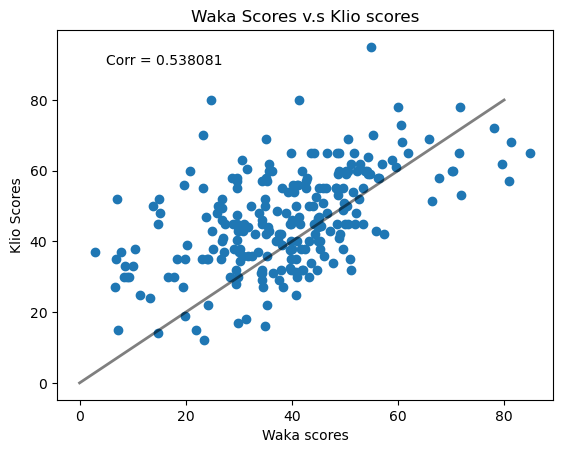

In [5]:
fig, ax = plt.subplots()
ax.scatter(waka_klio_merged['Imax'], waka_klio_merged['Preferred_Imax'])
ax.plot([0, 80], [0, 80], color='k', lw=2, alpha=0.5)
ax.set_xlabel('Waka scores')
ax.set_ylabel('Klio Scores')
ax.set_title('Waka Scores v.s Klio scores')
corr = waka_klio_merged['Imax'].corr(waka_klio_merged['Preferred_Imax'])
ax.text(5.0, 90, f'Corr = {corr:2f}')

plt.show()

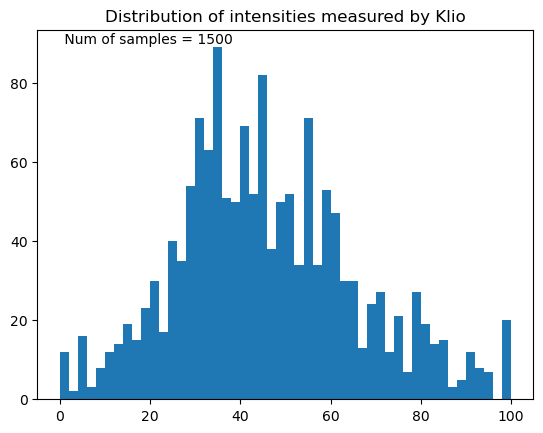

In [6]:
plt.hist(klio_df['Preferred_Imax'], bins=50)
plt.title('Distribution of intensities measured by Klio')
plt.text(0.0, 90.0, f" Num of samples = {len(klio_df)}")
plt.show()

In [7]:
dragon_df = pd.read_csv('data/raw_dragon_matrix.csv')
dragon_df.head()

,CID,MW,AMW,Sv,Se,Sp,Si,Mv,Me,Mp,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,126,122.130000,8.142,10.010,15.3050,10.193000,16.664000,0.667,1.020,0.680,...,66.806000,113.420000,0.864,-2.37,-2.42,-2.39,1.0,40.0,0.0,0
1,176,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,1.053,0.554,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.0,0
2,177,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,1.013,0.568,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.0,0
3,179,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,1.014,0.568,...,54.205000,92.700000,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.0,0
4,180,58.090000,5.809,5.295,9.9780,5.739000,11.455000,0.530,0.998,0.574,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.0,0


In [8]:
# Now, I need to merge klio db with Dragon by CAS

klio_dragon_merge = pd.merge(
    klio_df[['CID', 'Canonical_Name', 'Preferred_Imax']],
    dragon_df,
    how='left',
    on = 'CID'
)
print(f'The shape of the klio-daragon merged df is: {klio_dragon_merge.shape}')
klio_dragon_merge.head()


The shape of the klio-daragon merged df is: (1500, 2493)


,CID,Canonical_Name,Preferred_Imax,MW,AMW,Sv,Se,Sp,Si,Mv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,107,3-PHENYLPROPIONIC ACID,46.0,150.190000,7.152,13.064,21.0730,13.716000,23.495000,0.622,...,85.991000,148.020000,0.875,-3.16,-3.30,-3.31,1.0,48.0,0.028,0.0
1,125,4-HYDROXYBENZYL ALCOHOL,17.0,124.150000,7.303,10.537,17.1890,10.955000,19.080000,0.620,...,69.734000,116.060000,0.822,-2.22,-2.25,-2.21,1.0,40.0,0.052,0.0
2,176,ACETIC ACID,100.0,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.000,0.0
3,177,ACETALDEHYDE,59.0,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.000,0.0
4,179,ACETOIN NATURAL,49.0,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,...,54.205000,92.700000,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0


In [12]:
# here i want to check whether some Klio rows do not have Dragon descriptors
klio_dragon_merge.isna().sum()

CID                 0
Canonical_Name      0
Preferred_Imax      0
MW                230
AMW               230
                 ... 
BLTA96            230
nCIR              230
ZM1               230
R8u_              230
nRCOSR            230
Length: 2493, dtype: int64

In [13]:
klio_dragon_merge = klio_dragon_merge.dropna()

In [15]:
klio_dragon_merge.shape

(1270, 2493)

In [16]:
# Try retrieve the relevant descriptors according to the common knoledge and ref2
from ml_feature_matrix import build_ml_feature_matrix, raw_features_slice

feat_dict = {
    "f1_mass": 1,
    "f2_lipophilicity": 1,
    "f3_lipophilicity_extended": 4,
    "f4_volume": 1,
    "f5_volume": 1,
    "f6_volume": 1,
    "f7_surface_shape_Mor": 7,
    "f8_surface_shape_RDF": 8,
    "f9_whim": 4,
    "f10_geometry_topology": 8,
    "f11_spatial_autocorrelation": 8,
    "f12_polarity": 1,
    "f13_p_vsa_logp": 5,
    "f14_spdiam": 4,
}
features_df = raw_features_slice(klio_dragon_merge, start_col="MW")
mX_df = build_ml_feature_matrix(features_df, feat_dict)  

In [17]:
mX_df.head()

,f1_mass_PC1,f2_lipophilicity_PC1,f3_lipophilicity_extended_PC1,f3_lipophilicity_extended_PC2,f3_lipophilicity_extended_PC3,f3_lipophilicity_extended_PC4,f4_volume_PC1,f5_volume_PC1,f6_volume_PC1,f7_surface_shape_Mor_PC1,...,f12_polarity_PC1,f13_p_vsa_logp_PC1,f13_p_vsa_logp_PC2,f13_p_vsa_logp_PC3,f13_p_vsa_logp_PC4,f13_p_vsa_logp_PC5,f14_spdiam_PC1,f14_spdiam_PC2,f14_spdiam_PC3,f14_spdiam_PC4
0,-0.339736,-0.213838,-0.911470,0.293690,0.057528,-0.046211,-0.574365,-0.569379,-0.524164,9.086096,...,0.316104,-1.393543,0.595274,-0.873140,1.652575,0.001505,-0.217357,0.200109,-0.367428,-0.135155
1,-0.906510,-1.137342,-2.258906,-0.090317,0.094041,-0.095744,-1.150180,-1.174606,-1.064634,15.913197,...,-0.756593,-2.284690,-1.046204,-0.620166,1.548799,-0.212818,-0.457339,-0.127499,-0.808707,-0.333714
2,-2.301462,-2.277305,-3.432037,-0.887230,0.540980,-0.114197,-2.339161,-2.272197,-2.359452,12.506197,...,-3.549651,-1.618900,1.565664,-2.278946,0.365941,-0.269970,-4.064449,0.394922,-0.401727,-0.277010
3,-2.359900,-2.219638,-3.390493,-0.839518,0.513907,-0.120846,-2.339161,-2.272772,-2.359452,11.042054,...,-2.638871,-1.475503,0.870145,-2.210814,-0.220998,-0.446207,-6.499537,1.009301,0.254352,-0.394590
4,-1.690722,-2.143585,-3.408808,-0.797648,0.576117,-0.232740,-1.700210,-1.616976,-1.706268,8.002346,...,-2.881745,-1.502598,-0.744104,-1.321878,0.368048,-0.159813,-1.587390,-0.076790,-0.908007,0.187344


In [18]:
mX = mX_df.to_numpy()
vY = klio_dragon_merge['Preferred_Imax'].to_numpy()

In [30]:
kF = KFold(n_splits=10, shuffle=True, random_state=42)

In [27]:
dummy_regressor = DummyRegressor(strategy="mean")
dummy_predictions = cross_val_predict(
    dummy_regressor,
    mX,
    vY,
    cv=kF,
    n_jobs=-1,
    verbose=4)

dummy_mae = mean_absolute_error(vY, dummy_predictions)
print(f"Dummy MAE: {dummy_mae}")

dummy_r2 = r2_score(vY, dummy_predictions)
print(f"Dummy R2: {dummy_r2}")

Dummy MAE: 15.892199710480186
Dummy R2: -0.0019026714878975781


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
#oLinearRegressor = LinearRegression()

In [28]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])
vYPred = cross_val_predict(pipe, mX, vY, cv = kF, n_jobs=-1)

mae = mean_absolute_error(vY, vYPred)
print(mae)

r2 = r2_score(vY, vYPred)
print(r2)

13.14393953471851
0.31861131723224345


In [21]:
# SVR model with comprehensive grid search

# Same grid spirit as svr_kernel_Imax.ipynb
vC = [0.01, 0.1, 1, 10, 100, 1000]
vEpsilon = [0.01, 0.05, 0.1, 0.5, 1.0]
vGamma = ["scale", "auto", 0.001, 0.01, 0.1, 1]
lParamGrid = [
  {
    "svr__kernel": ["linear"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
  },
  {
    "svr__kernel": ["rbf"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": vGamma,
  },
  {
    "svr__kernel": ["poly"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "svr__degree": [2, 3, 4],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
  {
    "svr__kernel": ["sigmoid"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
]

pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(max_iter=50_000)),
])


In [31]:
oGsSvr = GridSearchCV(
    estimator=pipe_svr,
    param_grid=lParamGrid,
    scoring="neg_mean_absolute_error",
    cv=kF,
    n_jobs=-1,
    refit=True,
    verbose=4,
)
oGsSvr.fit(mX, vY)
print(f"Best CV MAE: {-oGsSvr.best_score_:.2f} ")
print("Best parameters:", oGsSvr.best_params_)

Fitting 10 folds for each of 2010 candidates, totalling 20100 fits
Best CV MAE: 11.72 
Best parameters: {'svr__C': 10, 'svr__epsilon': 1.0, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}


In [32]:
vYPred =  cross_val_predict(oGsSvr.best_estimator_, mX, vY, cv=10)
mae = mean_absolute_error(vY, vYPred)
r2 = r2_score(vY, vYPred)

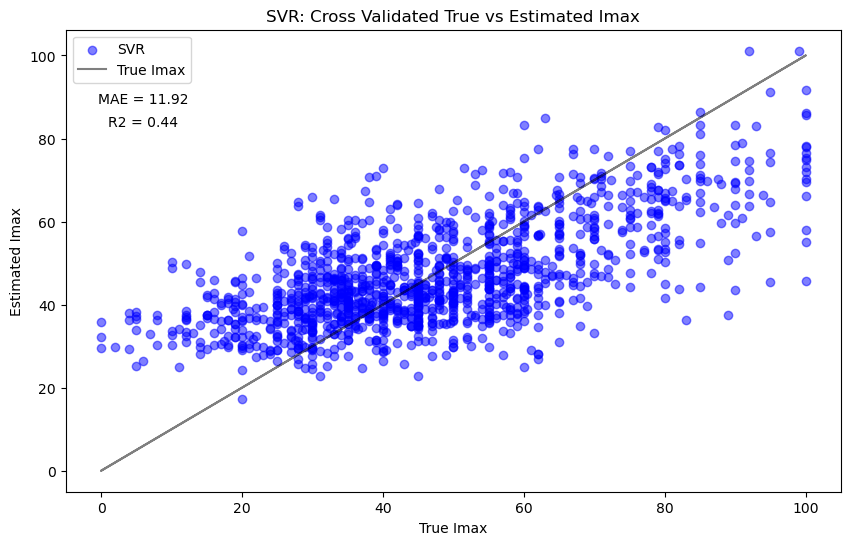

In [33]:
# now let's plot the results
plt.figure(figsize=(10, 6))
plt.scatter(vY, vYPred, label='SVR', color='blue', alpha=0.5)
plt.plot(vY, vY, label='True Imax', color='black', alpha=0.5)
plt.xlabel('True Imax')
plt.ylabel('Estimated Imax')
plt.title('SVR: Cross Validated True vs Estimated Imax')
plt.text(0.1, 0.85, f'MAE = {mae:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.text(0.1, 0.8, f'R2 = {r2:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.legend()
plt.show()

In [34]:
from xgboost import XGBRegressor

In [35]:
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

xgb_basic = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

vY_pred_xgb = cross_val_predict(
    xgb_basic,
    mX,
    vY,
    cv=cv,
    n_jobs=-1
)

xgb_mae = mean_absolute_error(vY, vY_pred_xgb)
xgb_r2 = r2_score(vY, vY_pred_xgb)

print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost R2: {xgb_r2:.2f}")

XGBoost MAE: 11.63
XGBoost R2: 0.46


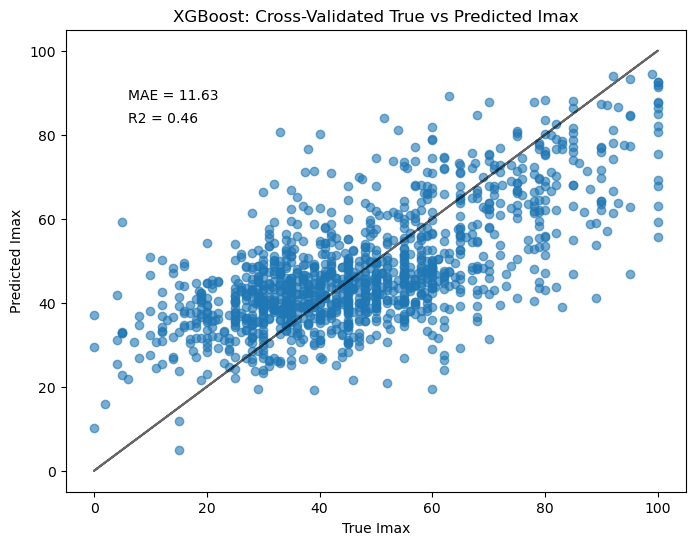

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(vY, vY_pred_xgb, alpha=0.6)
plt.plot(vY, vY, color="black", alpha=0.6)
plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title("XGBoost: Cross-Validated True vs Predicted Imax")
plt.text(0.1, 0.85, f"MAE = {xgb_mae:.2f}", transform=plt.gca().transAxes)
plt.text(0.1, 0.80, f"R2 = {xgb_r2:.2f}", transform=plt.gca().transAxes)
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

cv_tune = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv_tune,
    n_jobs=-1,
    verbose=2,
    refit=True
)

gs_xgb.fit(mX, vY)

print(f"Best XGBoost CV MAE: {-gs_xgb.best_score_:.2f}")
print("Best parameters:")
print(gs_xgb.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best XGBoost CV MAE: 11.62
Best parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}


In [38]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

xgb_mae = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

vYPred = cross_val_predict(
    xgb_mae,
    mX,
    vY,
    cv=cv,
    n_jobs=-1
)

mae = mean_absolute_error(vY, vYPred)
r2 = r2_score(vY, vYPred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

MAE: 11.88
R²: 0.435


In [39]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

xgb = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(mX, vY)

print("Best MAE:", -grid.best_score_)
print("Best parameters:")
print(grid.best_params_)

Fitting 10 folds for each of 432 candidates, totalling 4320 fits
Best MAE: 11.71124725592105
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.7}


In [40]:
objectives = [
    'reg:squarederror',
    'reg:absoluteerror',
    'reg:pseudohubererror'
]

for objective in objectives:

    model = XGBRegressor(
        objective=objective,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pred = cross_val_predict(
        model,
        mX,
        vY,
        cv=cv,
        n_jobs=-1
    )

    mae = mean_absolute_error(vY, pred)

    print(f"{objective}: MAE={mae:.2f}")

reg:squarederror: MAE=11.61
reg:absoluteerror: MAE=11.88
reg:pseudohubererror: MAE=356.62
